# Customer Segmentation & RFM Analysis

## Objective
Segment customers based on their purchasing behavior using the RFM framework (Recency, Frequency, Monetary) to identify high-value customers, at-risk customers, and inform targeted marketing/retention strategies.

## Note on Data Scope
This dataset covers a single month (November 2019). As a result, "Recency" is measured in days within this observation window rather than across a long-term customer lifecycle. This is a known limitation, transparently addressed in the analysis.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/sample_15pct.csv", parse_dates=['event_time'])
df.shape

(10125297, 9)

## Building Customer-Level Purchase Data
Filtering to purchase events only, since RFM is based on actual completed transactions.

In [2]:
purchases = df[df['event_type'] == 'purchase'].copy()
print(f"Total purchase events: {purchases.shape[0]:,}")
print(f"Unique customers who purchased: {purchases['user_id'].nunique():,}")

Total purchase events: 137,931
Unique customers who purchased: 108,648


## Calculating RFM Metrics

- **Recency:** Days since the customer's last purchase (relative to the last date in the dataset)
- **Frequency:** Total number of purchases made by the customer
- **Monetary:** Total amount spent by the customer

In [3]:
snapshot_date = df['event_time'].max()

rfm = purchases.groupby('user_id').agg(
    recency=('event_time', lambda x: (snapshot_date - x.max()).days),
    frequency=('event_time', 'count'),
    monetary=('price', 'sum')
).reset_index()

rfm.head(10)

,user_id,recency,frequency,monetary
0,253299396,24,1,246.85
1,282274853,22,1,79.15
2,304707635,17,1,2007.52
3,315835876,6,1,169.89
4,322601769,6,1,40.93
5,353600697,10,1,88.03
6,369801696,18,1,952.07
7,391549292,18,1,41.16
8,404851685,6,1,56.63
9,413392390,7,1,156.76


## RFM Scoring
Converting Recency, Frequency, and Monetary into 1–5 scores using quantile-based binning:
- **Recency:** Lower days = higher score (more recent = better)
- **Frequency:** Higher count = higher score
- **Monetary:** Higher spend = higher score

In [4]:
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1], duplicates='drop')
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5], duplicates='drop')
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5], duplicates='drop')

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head(10)

,user_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,253299396,24,1,246.85,1,1,3,113
1,282274853,22,1,79.15,1,1,2,112
2,304707635,17,1,2007.52,2,1,5,215
3,315835876,6,1,169.89,5,1,3,513
4,322601769,6,1,40.93,5,1,1,511
5,353600697,10,1,88.03,4,1,2,412
6,369801696,18,1,952.07,2,1,5,215
7,391549292,18,1,41.16,2,1,1,211
8,404851685,6,1,56.63,5,1,1,511
9,413392390,7,1,156.76,4,1,3,413


## Customer Segmentation
Mapping RFM scores into actionable business segments using standard RFM segmentation logic.

In [5]:
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 4 and f >= 2:
        return 'Loyal Customers'
    elif r >= 4 and f == 1:
        return 'New Customers'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk (High Value)'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

segment_summary = rfm['segment'].value_counts()
segment_summary

segment
Loyal Customers         36762
Needs Attention         23712
Lost Customers          15599
Champions               14838
New Customers           12034
At Risk (High Value)     5703
Name: count, dtype: int64

## Segment-Wise Revenue Contribution
Determining which customer segments contribute the most to total revenue, to prioritize retention and marketing efforts.


In [6]:
segment_revenue = rfm.groupby('segment').agg(
    customer_count=('user_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_revenue_per_customer=('monetary', 'mean')
).sort_values('total_revenue', ascending=False)

segment_revenue['revenue_share_%'] = (segment_revenue['total_revenue'] / segment_revenue['total_revenue'].sum()) * 100
segment_revenue

,customer_count,total_revenue,avg_revenue_per_customer,revenue_share_%
segment,,,,
Champions,14838,14282825.22,962.584258,34.455972
Loyal Customers,36762,8347584.70,227.071016,20.137763
Needs Attention,23712,6377784.45,268.968642,15.385805
At Risk (High Value),5703,4768063.43,836.062323,11.502505
Lost Customers,15599,4248029.68,272.327052,10.247972
New Customers,12034,3428105.94,284.868368,8.269983


## Key Insight
Just **13.7% of customers (Champions)** generate **34.5% of total revenue** — a clear Pareto-style concentration, consistent with the category/brand-level findings from Project 1. Critically, the **"At Risk (High Value)" segment** — though small (5,703 customers) — has the second-highest average revenue per customer ($836), meaning these are high-value customers who haven't purchased recently. Losing them would represent a disproportionately large revenue loss relative to their small size.

**Business Recommendation:** 
1. Prioritize retention campaigns (personalized offers, loyalty rewards) for Champions to protect the 34.5% revenue base.
2. Launch an urgent win-back campaign (targeted discounts, re-engagement emails) for the At Risk (High Value) segment before they fully churn — recovering even 20% of this segment could preserve ~$950K in revenue.
3. For New Customers (12,034), focus on second-purchase incentives to convert them into Loyal Customers.

## Segment Revenue Visualization

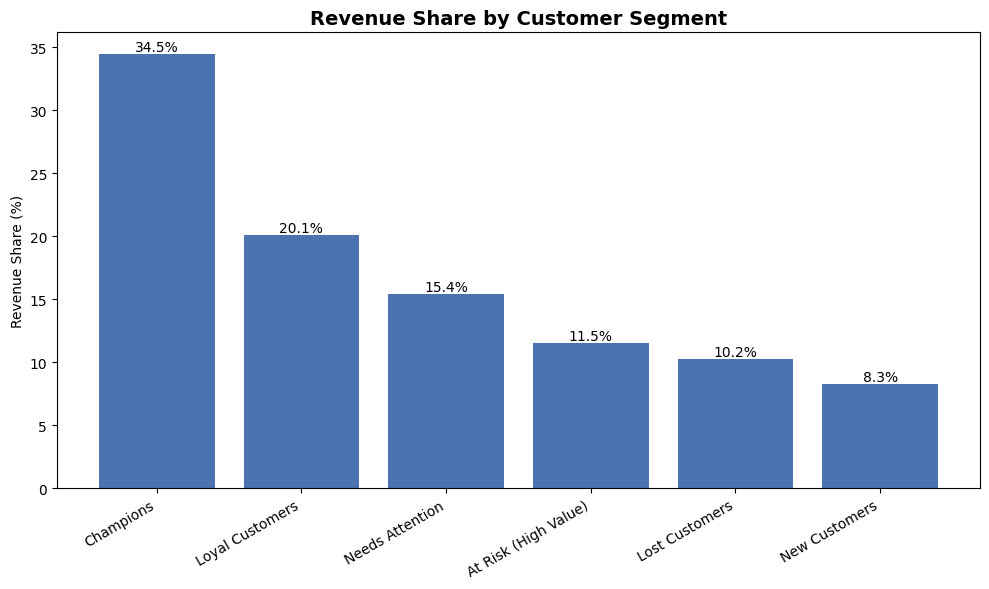

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
bars = plt.bar(segment_revenue.index, segment_revenue['revenue_share_%'], color='#4C72B0')
plt.title('Revenue Share by Customer Segment', fontsize=14, fontweight='bold')
plt.ylabel('Revenue Share (%)')
plt.xticks(rotation=30, ha='right')

for bar, value in zip(bars, segment_revenue['revenue_share_%']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.1f}%', 
              ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("../Reports/segment_revenue_chart.png", dpi=150)
plt.show()

## Customer Count vs Revenue Share Comparison
Comparing each segment's share of total customers against its share of total revenue — highlighting disproportionate value concentration.

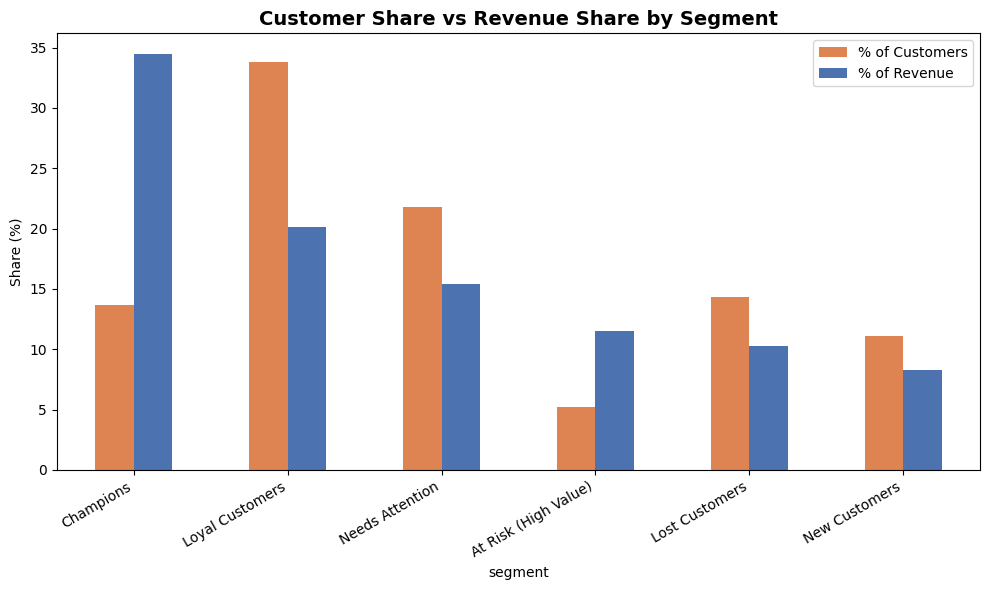

In [8]:
segment_revenue['customer_share_%'] = (segment_revenue['customer_count'] / segment_revenue['customer_count'].sum()) * 100

comparison = segment_revenue[['customer_share_%', 'revenue_share_%']]

comparison.plot(kind='bar', figsize=(10,6), color=['#DD8452', '#4C72B0'])
plt.title('Customer Share vs Revenue Share by Segment', fontsize=14, fontweight='bold')
plt.ylabel('Share (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(['% of Customers', '% of Revenue'])
plt.tight_layout()
plt.savefig("../Reports/customer_vs_revenue_share_chart.png", dpi=150)
plt.show()

## Summary
Champions represent only 13.7% of customers but drive 34.5% of revenue — a 2.5x overrepresentation. This confirms that customer value is highly concentrated, reinforcing the need for segment-specific retention and marketing strategies rather than a one-size-fits-all approach.

In [9]:
rfm.to_csv("../Reports/rfm_customer_data.csv", index=False)
segment_revenue.reset_index().to_csv("../Reports/segment_revenue_summary.csv", index=False)

print("Notebook 5 exports done")

Notebook 5 exports done
